#  2.5 Seaborn — Fundamentos

Seaborn es una biblioteca estadística construida **sobre Matplotlib**.
Produce gráficos hermosos con muy poco código e integra directamente con Pandas.

| Característica | Matplotlib | Seaborn |
|---|---|---|
| Nivel de abstracción | Bajo | Alto |
| Integración Pandas | Manual | Nativa |
| Estética por defecto | Básica | Lista para publicar |
| Gráficos estadísticos | Manual | Incorporados |

In [1]:
import seaborn as sns
# seaborn  → la biblioteca completa
# as sns   → alias estándar universal

import matplotlib.pyplot as plt
# Siempre importamos matplotlib:
# Seaborn lo usa internamente y necesitamos plt.show()

import pandas as pd
import numpy as np

sns.set_theme(
    style='whitegrid',  # fondo: 'white','whitegrid','dark','darkgrid','ticks'
    palette='husl',     # paleta de colores por defecto
    font_scale=1.1)     # escala de todas las fuentes (multiplicador)

# Datasets incluidos en Seaborn (perfectos para practicar)
tips     = sns.load_dataset('tips')      # propinas en restaurante
iris     = sns.load_dataset('iris')      # medidas de flores
penguins = sns.load_dataset('penguins')  # pingüinos de Palmer

print('Dataset tips:')
print(tips.head())
print(f'Columnas: {list(tips.columns)}')
print(f'Shape:    {tips.shape}')

Dataset tips:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
Columnas: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']
Shape:    (244, 7)


## 3.1 Distribuciones

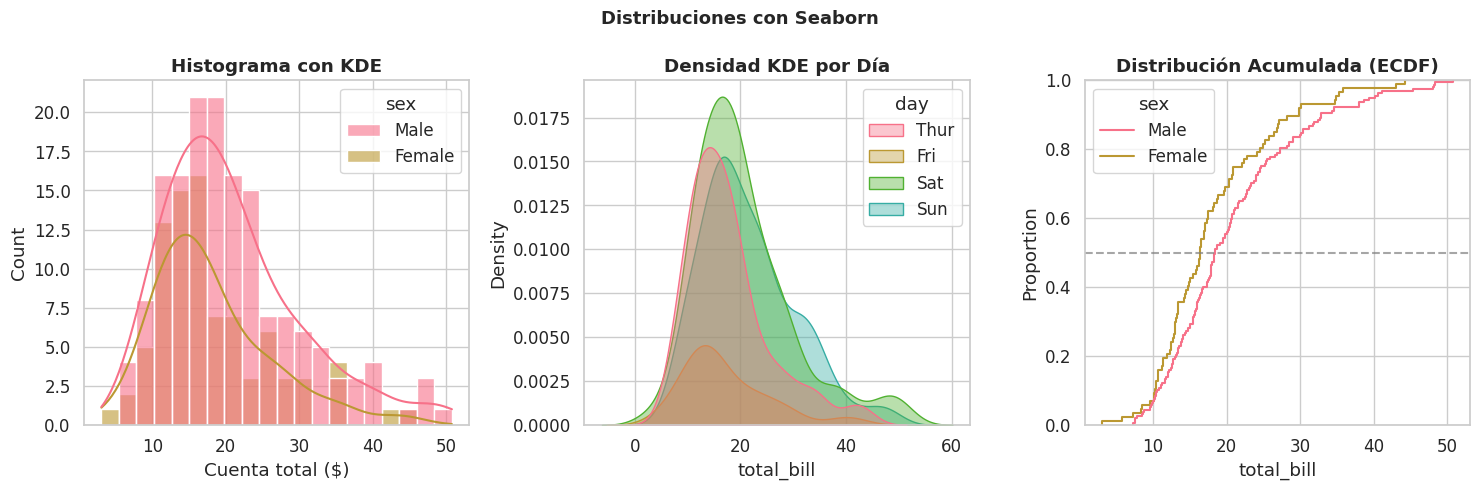

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# histplot — histograma mejorado
sns.histplot(
    data=tips,         # el DataFrame
    x='total_bill',    # columna para el eje X
    hue='sex',         # colorear por categoría
    # 'hue' es uno de los parámetros más poderosos de Seaborn
    kde=True,          # True = superpone curva de densidad (KDE)
    bins=20,
    alpha=0.6,
    ax=axes[0])        # en qué Axes dibujar

axes[0].set_title('Histograma con KDE', fontweight='bold')
axes[0].set_xlabel('Cuenta total ($)')

# kdeplot — curva de densidad (Kernel Density Estimation)
# KDE es una versión suavizada del histograma
# Estima la densidad de probabilidad de los datos
sns.kdeplot(
    data=tips,
    x='total_bill',
    hue='day',
    fill=True,         # rellenar el área bajo la curva
    alpha=0.4,
    bw_adjust=0.8,     # ancho de banda del suavizado
    # < 1 → más detalle | > 1 → más suave
    ax=axes[1])

axes[1].set_title('Densidad KDE por Día', fontweight='bold')

# ecdfplot — distribución acumulada empírica
# ECDF(x) = fracción de datos MENORES que x
# Ej: ECDF(25)=0.7 → el 70% de las cuentas son < $25
sns.ecdfplot(
    data=tips,
    x='total_bill',
    hue='sex',
    ax=axes[2])

axes[2].set_title('Distribución Acumulada (ECDF)', fontweight='bold')
axes[2].axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Mediana')

plt.suptitle('Distribuciones con Seaborn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.2 Gráficos relacionales

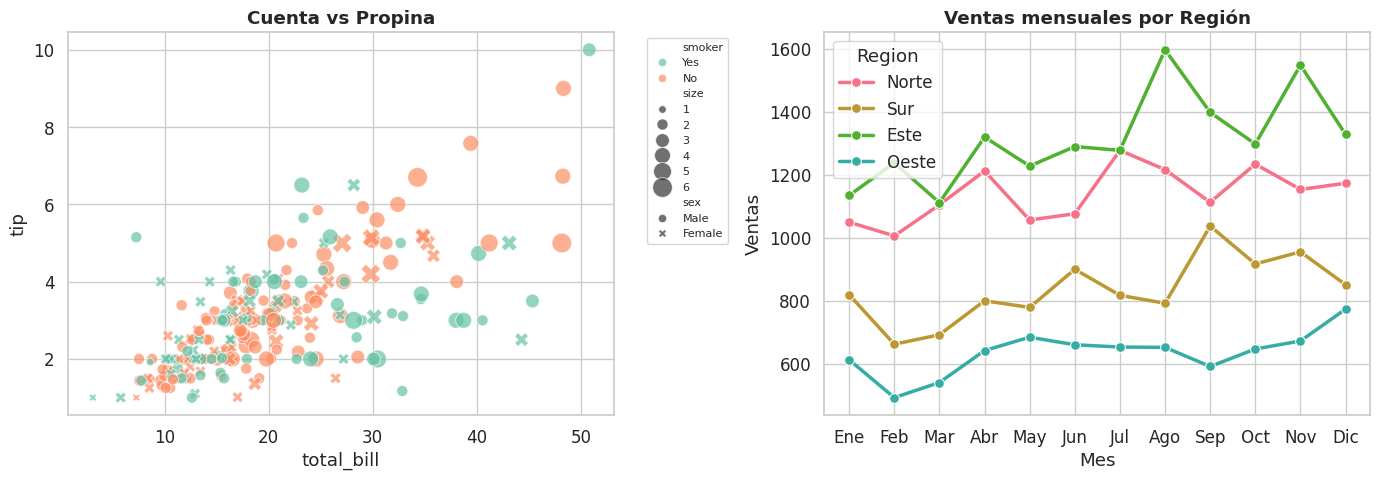

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scatterplot
sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='smoker',      # color por categoría
    style='sex',       # forma del marcador por categoría
    size='size',       # tamaño del marcador por variable numérica
    sizes=(30, 200),   # rango de tamaños (mínimo, máximo) en puntos²
    alpha=0.7,
    palette='Set2',
    ax=axes[0])

axes[0].set_title('Cuenta vs Propina', fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
# bbox_to_anchor → coloca la leyenda FUERA del gráfico a la derecha

# lineplot — línea con intervalo de confianza automático
# Cuando hay múltiples y por cada x, muestra la MEDIA + IC 95%
np.random.seed(42)
meses  = list(range(1, 13)) * 4
region = ['Norte']*12 + ['Sur']*12 + ['Este']*12 + ['Oeste']*12
vts    = ([1000 + np.random.randn()*100 + i*20 for i in range(12)] +
          [800  + np.random.randn()*80  + i*15 for i in range(12)] +
          [1200 + np.random.randn()*120 + i*25 for i in range(12)] +
          [600  + np.random.randn()*60  + i*10 for i in range(12)])
df_v = pd.DataFrame({'Mes':meses,'Region':region,'Ventas':vts})

sns.lineplot(
    data=df_v, x='Mes', y='Ventas', hue='Region',
    linewidth=2.5, marker='o', markersize=7,
    dashes=False,      # False = todas las líneas sólidas
    ax=axes[1])

axes[1].set_title('Ventas mensuales por Región', fontweight='bold')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                          'Jul','Ago','Sep','Oct','Nov','Dic'])

plt.tight_layout()
plt.show()

## 3.3 Gráficos categóricos

/tmp/ipykernel_374/22761722.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins.dropna(), x='species', y='body_mass_g',


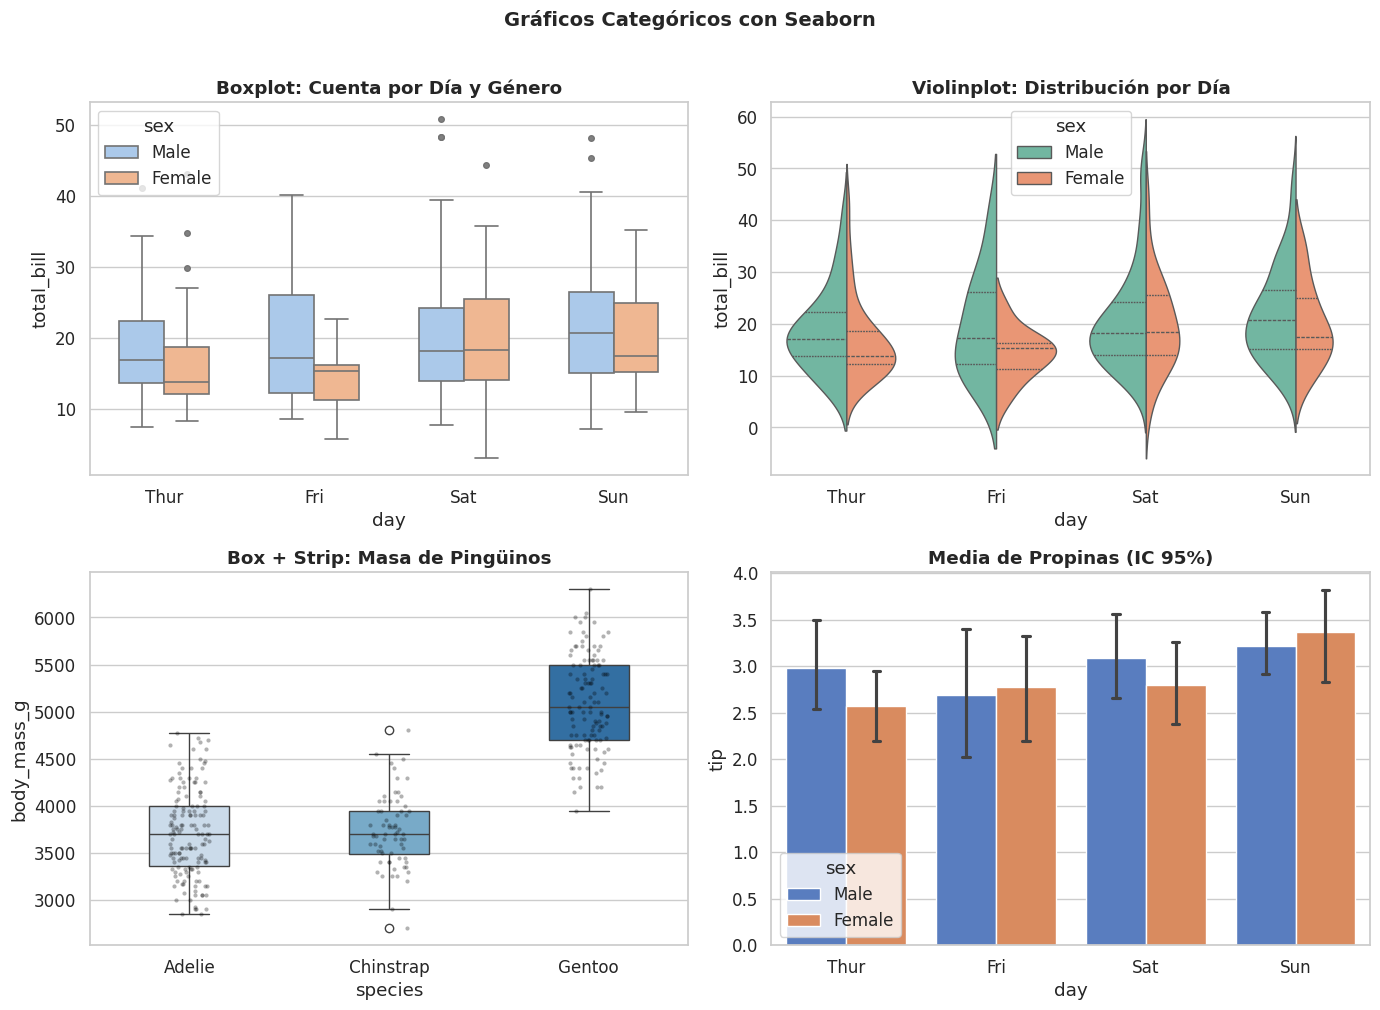

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# boxplot
sns.boxplot(
    data=tips, x='day', y='total_bill', hue='sex',
    palette='pastel', width=0.6, linewidth=1.2,
    flierprops={'marker':'o','markerfacecolor':'gray','markersize':4},
    # flierprops → propiedades de los puntos atípicos (outliers)
    ax=axes[0, 0])
axes[0, 0].set_title('Boxplot: Cuenta por Día y Género', fontweight='bold')

# violinplot — combina boxplot con curva KDE
# Muestra la distribución completa, no solo los cuartiles
sns.violinplot(
    data=tips, x='day', y='total_bill', hue='sex',
    split=True,       # True = divide el violín por las 2 categorías de hue
    inner='quart',    # qué mostrar dentro:
    # 'box'=boxplot | 'quart'=cuartiles | 'point'=puntos | None=nada
    palette='Set2', linewidth=1,
    ax=axes[0, 1])
axes[0, 1].set_title('Violinplot: Distribución por Día', fontweight='bold')

# Box + Strip superpuestos (técnica avanzada)
# Muestra datos individuales Y el resumen estadístico
sns.boxplot(data=penguins.dropna(), x='species', y='body_mass_g',
            palette='Blues', width=0.4, ax=axes[1, 0])
sns.stripplot(
    data=penguins.dropna(), x='species', y='body_mass_g',
    color='black', alpha=0.3, size=3,
    jitter=True,  # jitter → añade ruido horizontal para ver puntos superpuestos
    ax=axes[1, 0])
axes[1, 0].set_title('Box + Strip: Masa de Pingüinos', fontweight='bold')

# barplot — muestra la MEDIA con intervalo de confianza 95%
# Diferente a plt.bar() que muestra valores directos
sns.barplot(
    data=tips, x='day', y='tip', hue='sex',
    palette='muted',
    capsize=0.1,      # tamaño de los sombreros en las barras de error
    errorbar='ci',    # tipo de barra: 'ci'=IC | 'sd'=desv. estándar
    ax=axes[1, 1])
axes[1, 1].set_title('Media de Propinas (IC 95%)', fontweight='bold')

plt.suptitle('Gráficos Categóricos con Seaborn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 3.4 Heatmap

/tmp/ipykernel_374/3092849961.py:27: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = tips.pivot_table(values='tip', index='day',


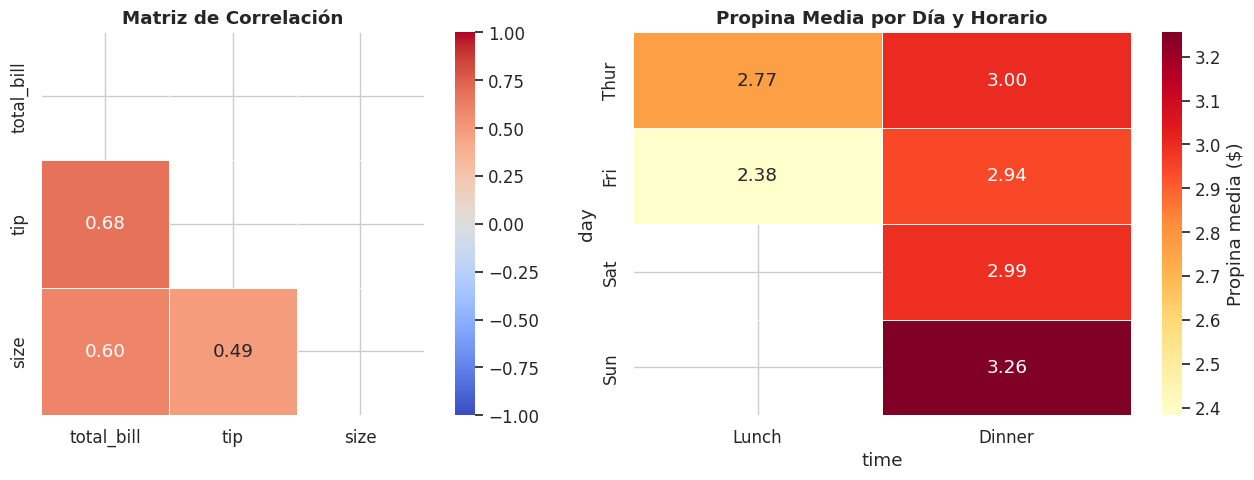

In [5]:
correlacion = tips.select_dtypes(include='number').corr()
# corr() → correlación de Pearson entre columnas numéricas
# Rango: -1 (inversa perfecta) a +1 (directa perfecta)
# select_dtypes(include='number') → solo columnas numéricas

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mask = np.triu(np.ones_like(correlacion, dtype=bool))
# np.triu()     → triángulo SUPERIOR de la matriz (con diagonal)
# np.ones_like  → matriz de unos del mismo tamaño
# Combinados: máscara para ocultar la mitad superior (idéntica a la inferior)

sns.heatmap(
    correlacion,
    mask=mask,         # True = ocultar esa celda
    annot=True,        # True = muestra el valor en cada celda
    fmt='.2f',         # formato: 2 decimales
    cmap='coolwarm',   # azul(neg) → blanco(0) → rojo(pos)
    vmin=-1, vmax=1,   # rango fijo de la escala
    center=0,          # valor central del colormap
    linewidths=0.5,
    linecolor='white',
    square=True,       # True = celdas cuadradas
    ax=axes[0])
axes[0].set_title('Matriz de Correlación', fontweight='bold')

pivot = tips.pivot_table(values='tip', index='day',
                          columns='time', aggfunc='mean')
# pivot_table → tabla dinámica
# aggfunc='mean' → función de agregación | otras: 'sum','count','median'

sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Propina media ($)'},
            ax=axes[1])
axes[1].set_title('Propina Media por Día y Horario', fontweight='bold')

plt.tight_layout()
plt.show()

## 3.5 Pairplot — visualización multivariada

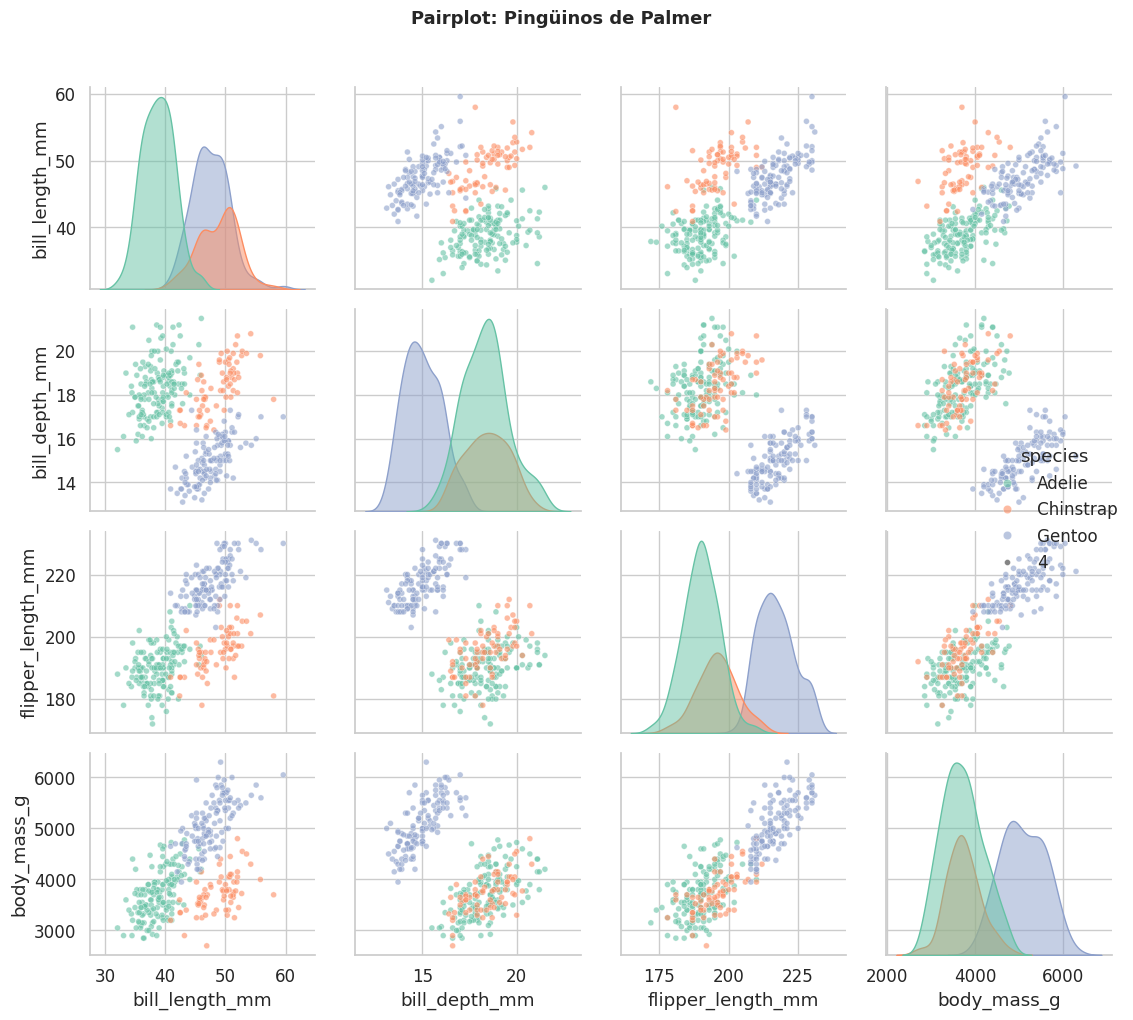

In [6]:
# pairplot → MATRIZ de gráficos
#   Diagonal      → distribución de cada variable
#   Fuera diagonal → scatter de cada par de variables

g = sns.pairplot(
    penguins.dropna(),
    hue='species',
    diag_kind='kde',   # tipo en diagonal: 'hist' o 'kde'
    plot_kws={'alpha':0.6,'size':4},
    diag_kws={'fill':True,'alpha':0.5},
    palette='Set2',
    corner=False)      # False=matriz completa | True=solo triángulo inferior

g.figure.suptitle('Pairplot: Pingüinos de Palmer', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()